<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/Basic_ML_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practice

Data: cleaned data for heart disease

V1 -> ID column to be dropped
V58 -> target column ( heart disease 1 / healthy 0 )


Models:
- Decision Tree
- Logistic Regression
- Naive Bayes
- SVM
- KNN


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/cleaned_76hd.csv")

In [ ]:
df.columns

Index(['V1', 'V3', 'V4', 'V9', 'V10', 'V11', 'V12', 'V14', 'V15', 'V16', 'V18',
       'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28',
       'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V37', 'V38', 'V39',
       'V40', 'V41', 'V43', 'V44', 'V51', 'V55', 'V56', 'V57', 'V58'],
      dtype='object')

In [ ]:
df = df.drop('V1', axis=1)

# X &Y

In [ ]:
X = df.drop('V58',axis=1)
y = df.loc[:,'V58']

In [ ]:
y.value_counts()

,count
V58,
0.0,154
1.0,128


# Train test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,
                                                 random_state=7,
                                                 stratify=y)

In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((197, 38), (85, 38), (197,), (85,))

# Apply Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state = 7,class_weight="balanced")

In [ ]:
dt.fit(X_train,y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=7)

In [ ]:
dt.feature_importances_

array([8.05909106e-02, 6.89441814e-02, 8.00233087e-02, 4.52420930e-02,
       0.00000000e+00, 1.75267862e-02, 1.34723693e-16, 0.00000000e+00,
       3.36216725e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.75429717e-02, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.04394286e-02, 0.00000000e+00, 5.68159010e-02, 3.40143059e-02,
       4.05294175e-02, 4.03143913e-02, 7.48464960e-18, 1.69339120e-02,
       0.00000000e+00, 0.00000000e+00, 4.29060617e-02, 0.00000000e+00,
       3.37528312e-02, 1.25354404e-01, 2.85706928e-01, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [ ]:
y_pred = dt.predict(X_test)

In [ ]:
y_pred.shape, y_test.shape

((85,), (85,))

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
precision_recall_fscore_support(y_test,y_pred)

(array([0.78571429, 0.69767442]),
 array([0.7173913 , 0.76923077]),
 array([0.75      , 0.73170732]),
 array([46, 39]))

In [ ]:
accuracy_score(y_test,y_pred)

0.7411764705882353

In [ ]:
confusion_matrix(y_test,y_pred)

array([[33, 13],
       [ 9, 30]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.72      0.75        46
         1.0       0.70      0.77      0.73        39

    accuracy                           0.74        85
   macro avg       0.74      0.74      0.74        85
weighted avg       0.75      0.74      0.74        85



## Vizualize Decision Tree

In [ ]:
from sklearn.tree import export_text

In [ ]:
print(export_text(dt))

|--- feature_34 <= 0.88
|   |--- feature_33 <= 0.17
|   |   |--- feature_23 <= 0.19
|   |   |   |--- class: 1.0
|   |   |--- feature_23 >  0.19
|   |   |   |--- feature_3 <= 0.79
|   |   |   |   |--- feature_30 <= 0.27
|   |   |   |   |   |--- feature_20 <= 0.13
|   |   |   |   |   |   |--- feature_22 <= 0.01
|   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- feature_22 >  0.01
|   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- feature_20 >  0.13
|   |   |   |   |   |   |--- feature_24 <= 0.10
|   |   |   |   |   |   |   |--- feature_3 <= 0.54
|   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |--- feature_3 >  0.54
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- feature_24 >  0.10
|   |   |   |   |   |   |   |--- feature_8 <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- feature_8 >  0.50
|   |   |   |   |   |   |   |   |--- feature_24 <= 0.23
|   |   |

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(random_state=7,solver='saga',class_weight="balanced")
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.76      0.79        46
         1.0       0.74      0.79      0.77        39

    accuracy                           0.78        85
   macro avg       0.78      0.78      0.78        85
weighted avg       0.78      0.78      0.78        85



/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# Naive Bayes

- Guassian
- Multi-nomial
- Bernoullis

In [ ]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB

# SVM

In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf')
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.81      0.83      0.82        46
         1.0       0.79      0.77      0.78        39

    accuracy                           0.80        85
   macro avg       0.80      0.80      0.80        85
weighted avg       0.80      0.80      0.80        85



In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf',C=10)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.79      0.80      0.80        46
         1.0       0.76      0.74      0.75        39

    accuracy                           0.78        85
   macro avg       0.78      0.77      0.77        85
weighted avg       0.78      0.78      0.78        85



In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf',C=0.1)
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.77      0.87      0.82        46
         1.0       0.82      0.69      0.75        39

    accuracy                           0.79        85
   macro avg       0.79      0.78      0.78        85
weighted avg       0.79      0.79      0.79        85



In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf',gamma=0.5) #gamma ='scale'
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80        46
         1.0       0.77      0.77      0.77        39

    accuracy                           0.79        85
   macro avg       0.79      0.79      0.79        85
weighted avg       0.79      0.79      0.79        85



In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf',gamma=0.1) #gamma ='scale'
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.80      0.81        46
         1.0       0.78      0.79      0.78        39

    accuracy                           0.80        85
   macro avg       0.80      0.80      0.80        85
weighted avg       0.80      0.80      0.80        85



In [ ]:
from sklearn.svm import SVC
svc = SVC(random_state=7,kernel='rbf',gamma=10) #gamma ='scale'
svc.fit(X_train,y_train)
y_pred = svc.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.54      1.00      0.70        46
         1.0       0.00      0.00      0.00        39

    accuracy                           0.54        85
   macro avg       0.27      0.50      0.35        85
weighted avg       0.29      0.54      0.38        85



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# KNN

# Evaluate all the models using a single function

In [ ]:
def eval_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    p,r,f,s = precision_recall_fscore_support(y_test,y_pred)
    acc = accuracy_score(y_test,y_pred)
    # print(model.__class__)
    # print(prfs)
    # print(acc)
    return p,r,f,s,acc

## Create list of all models

In [ ]:
model_list = [DecisionTreeClassifier(random_state=7),
              LogisticRegression(random_state=7),
              GaussianNB(),
              BernoulliNB(),
              MultinomialNB(),
              SVC(random_state=7)]

In [ ]:
pc1 = []
pc2=[]
rc1=[]
rc2=[]
fc1=[]
fc2=[]
acc_list=[]
for model in model_list:
    p,r,f,s,acc = eval_model(model,X_train,X_test,y_train,y_test)
    pc1.append(p[0])
    pc2.append(p[1])
    rc1.append(r[0])
    rc2.append(r[1])
    fc1.append(f[0])
    fc2.append(f[1])
    acc_list.append(acc)

In [ ]:
result_dict = {
    "pc1" : pc1,
    "pc2" : pc2,
    "rc1" : rc1,
    "rc2" : rc2,
    "fc1" : fc1,
    "fc2" : fc2,
    "acc" : acc_list
}

In [ ]:
# Create DF using all lists

result_df = pd.DataFrame(result_dict)

In [ ]:
result_df

,pc1,pc2,rc1,rc2,fc1,fc2,acc
0,0.761905,0.674419,0.695652,0.743590,0.727273,0.707317,0.717647
1,0.822222,0.775000,0.804348,0.794872,0.813187,0.784810,0.800000
2,0.647887,1.000000,1.000000,0.358974,0.786325,0.528302,0.705882
3,0.829787,0.815789,0.847826,0.794872,0.838710,0.805195,0.823529
4,0.822222,0.775000,0.804348,0.794872,0.813187,0.784810,0.800000
5,0.808511,0.789474,0.826087,0.769231,0.817204,0.779221,0.800000


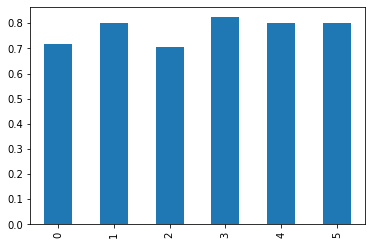

In [ ]:
result_df["acc"].plot.bar()

# How to Compare Different Model performance?

- f1-score

- Recall

- Precision

- Accuracy



# Simulation

Compare performance of a single algorithm, on multiple parts of the same data

In [ ]:
def sim(model,X,y):
    X_train,X_test,y_train,y_test = train_test_split(X,y,
                                                 test_size=0.3,
                                                 stratify=y)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    return acc

In [ ]:
sim_result = []
for i in range(10):
    model = SVC(random_state=7)
    acc = sim(model,X,y)
    sim_result.append(acc)

In [ ]:
sim_result

[0.8823529411764706,
 0.8705882352941177,
 0.7529411764705882,
 0.8470588235294118,
 0.8352941176470589,
 0.788235294117647,
 0.7411764705882353,
 0.8,
 0.8588235294117647,
 0.8235294117647058]

In [ ]:
sum(sim_result) / len(sim_result)

0.82